# Chapter 4 — Flow Matching / CFM (2-D)

**Theory reference**: `quickguide.tex` Chapter 4.

### What this notebook covers
1. Visualize straight-line OT-Gaussian paths and conditional velocities
2. Train a CFM model and inspect the learned marginal velocity field
3. Compare Euler vs. RK4 and NFE sweep
4. Visualize ODE trajectories (flow lines)
5. Compare against DDIM-50

### Key equations

**OT-Gaussian path**: $x_t = (1-(1-\sigma_{\min})t)\,x_0 + t\,x_1$

**Conditional velocity** (constant — straight lines!):
$u_t(x_t|x_0,x_1) = x_1 - (1-\sigma_{\min})\,x_0$

**CFM loss**: $\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t,x_0,x_1}\bigl[\|v_\theta(x_t,t) - u_t(x_t|x_0,x_1)\|^2\bigr]$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [17]:
from diffusion_lab.data import make_dataset, get_dataloader

DATASET = 'moons'     # ← try 'moons', 'checkerboard'
x0_np   = make_dataset(DATASET, n=5000, seed=0)
x0      = torch.from_numpy(x0_np).to(DEVICE)
loader  = get_dataloader(DATASET, n=20_000, batch_size=512, seed=0, device=DEVICE)

## 1  OT-Gaussian paths: straight lines from N(0,I) to data

### 1a  Straight-line paths and conditional velocity field

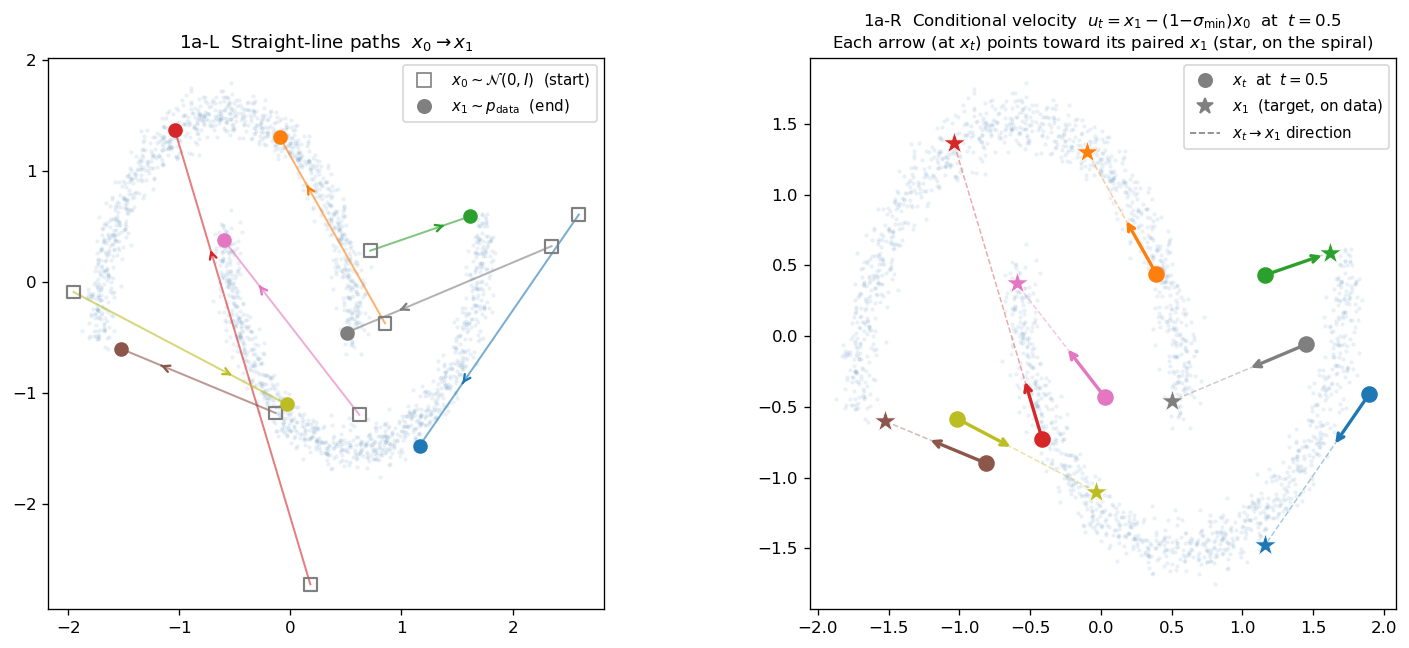

In [18]:
N_TRAJ    = 8
sigma_min = 1e-4
t_vals    = np.linspace(0, 1, 40)

x1_pts = torch.from_numpy(make_dataset(DATASET, n=N_TRAJ, seed=1)).to(DEVICE)
x0_pts = torch.randn_like(x1_pts)
x0_np_traj = x0_pts.cpu().numpy()
x1_np_traj = x1_pts.cpu().numpy()

paths = np.stack([
    np.array([(1 - (1 - sigma_min) * t) * x0_np_traj[i] + t * x1_np_traj[i]
              for t in t_vals])
    for i in range(N_TRAJ)
])

from matplotlib.lines import Line2D
colors = [plt.cm.tab10(i / N_TRAJ) for i in range(N_TRAJ)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: straight-line paths ─────────────────────────────────────────────
ax = axes[0]
plot_samples(x0_np[:2000], ax=ax, alpha=0.07, s=3, color='steelblue')

for i, c in enumerate(colors):
    path = paths[i]
    ax.plot(path[:, 0], path[:, 1], '-', lw=1.2, alpha=0.6, color=c)
    m = int(0.72 * len(path))
    ax.annotate('', xy=path[m + 1], xytext=path[m],
                arrowprops=dict(arrowstyle='->', color=c, lw=1.4))
    ax.scatter(*x0_np_traj[i], marker='s', s=60,
               facecolors='none', edgecolors='gray', lw=1.3, zorder=5)
    ax.scatter(*x1_np_traj[i], marker='o', s=60, color=c, zorder=5)

ax.legend(handles=[
    Line2D([0],[0], marker='s', color='gray', markerfacecolor='none',
           markersize=8, ls='None', label=r'$x_0 \sim \mathcal{N}(0,I)$  (start)'),
    Line2D([0],[0], marker='o', color='gray',
           markersize=8, ls='None', label=r'$x_1 \sim p_\mathrm{data}$  (end)'),
], fontsize=9)
ax.set_title('1a-L  Straight-line paths  $x_0 \\to x_1$', fontsize=11)
ax.set_aspect('equal')

# ── Right: conditional velocity with data background ─────────────────────
ax = axes[1]
# data distribution as faint background (same as left)
plot_samples(x0_np[:2000], ax=ax, alpha=0.07, s=3, color='steelblue')

t_mid = 0.5
t_idx = int(t_mid * (len(t_vals) - 1))

for i, c in enumerate(colors):
    xt  = paths[i][t_idx]
    ut  = x1_np_traj[i] - (1 - sigma_min) * x0_np_traj[i]
    u_n = ut / (np.linalg.norm(ut) + 1e-8)

    # dashed line x_t → x_1
    ax.plot([xt[0], x1_np_traj[i, 0]],
            [xt[1], x1_np_traj[i, 1]],
            '--', lw=0.9, alpha=0.4, color=c)
    # x_t: circle
    ax.scatter(*xt, marker='o', s=80, color=c, zorder=5)
    # x_1: star (larger so it stands out on the background)
    ax.scatter(*x1_np_traj[i], marker='*', s=200, color=c,
               edgecolors='white', linewidths=0.5, zorder=6)
    # velocity arrow
    ax.annotate('', xy=xt + 0.45 * u_n, xytext=xt,
                arrowprops=dict(arrowstyle='->', color=c, lw=2.0))

ax.legend(handles=[
    Line2D([0],[0], marker='o', color='gray',
           markersize=8, ls='None', label=r'$x_t$  at  $t=0.5$'),
    Line2D([0],[0], marker='*', color='gray',
           markersize=10, ls='None', label=r'$x_1$  (target, on data)'),
    Line2D([0],[0], color='gray', lw=1, ls='--',
           label=r'$x_t \to x_1$ direction'),
], fontsize=9)
ax.set_title('1a-R  Conditional velocity  $u_t = x_1 - (1{-}\\sigma_\\min)x_0$  at  $t=0.5$\n'
             'Each arrow (at $x_t$) points toward its paired $x_1$ (star, on the spiral)',
             fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 1b  Marginal distribution $x_t$ as $t$ goes from 0 → 1

At each $t$, the marginal is $x_t = (1-(1-\sigma_{\min})t)\,x_0 + t\,x_1$ with $x_0\sim\mathcal{N}(0,I)$, $x_1\sim p_\text{data}$.  
$t=0$: pure Gaussian noise.  $t=1$: data distribution.  Intermediate $t$: linear interpolation of the two.

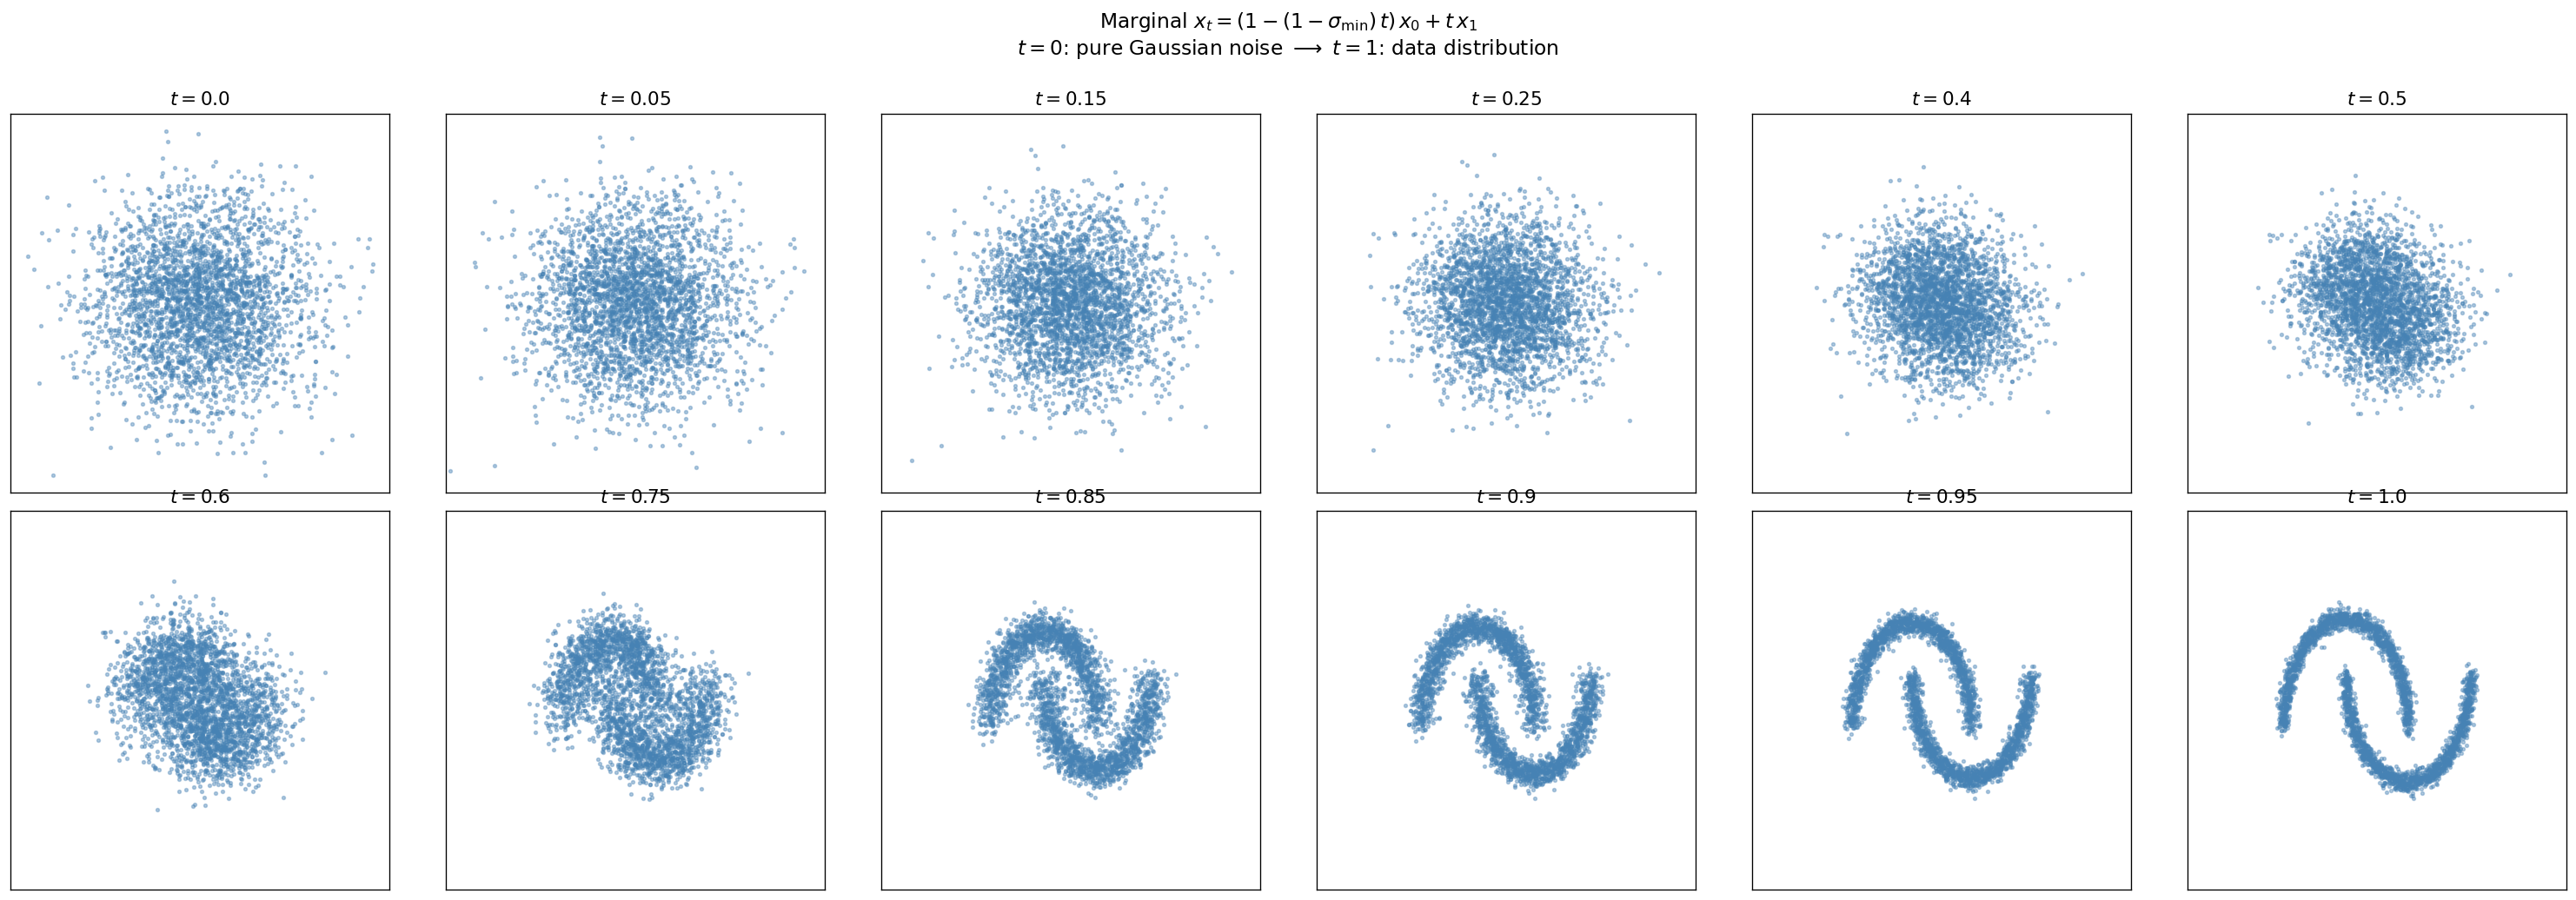

In [19]:
N_MARG    = 3000
sigma_min = 1e-4
t_show    = [0.0, 0.05, 0.15, 0.25, 0.4, 0.5,
             0.6,  0.75, 0.85, 0.9,  0.95, 1.0]

x1_marg = torch.from_numpy(make_dataset(DATASET, n=N_MARG, seed=42)).to(DEVICE)
x0_marg = torch.randn_like(x1_marg)

n_cols = len(t_show) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(4.2 * n_cols, 8.5))
axes_flat = axes.flatten()

for ax, t in zip(axes_flat, t_show):
    xt    = (1 - (1 - sigma_min) * t) * x0_marg + t * x1_marg
    xt_np = xt.cpu().numpy()

    ax.scatter(xt_np[:, 0], xt_np[:, 1],
               s=5, alpha=0.4, color='steelblue', rasterized=True)
    ax.set_title(f'$t = {t}$', fontsize=13, pad=6)
    ax.set_aspect('equal')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

plt.suptitle(
    r'Marginal $x_t = (1-(1-\sigma_{\min})\,t)\,x_0 + t\,x_1$'
    '\n'
    r'$t=0$: pure Gaussian noise $\longrightarrow$ $t=1$: data distribution',
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

## 2  Train CFM

In [20]:
from diffusion_lab.nn       import TimeMLP
from diffusion_lab.models   import CFM
from diffusion_lab.training import Trainer

network = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                  time_embed_dim=128, residual=True).to(DEVICE)
cfm     = CFM(network, sigma_min=1e-4).to(DEVICE)

trainer = Trainer(cfm, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
losses  = trainer.train(n_steps=20_000, log_every=1000)
print(f'Initial: {losses[0]:.4f}  Final: {losses[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial: 2.4082  Final: 1.3359


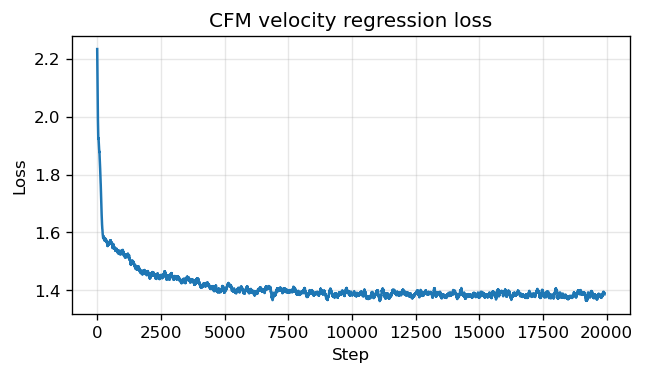

In [21]:
from diffusion_lab.utils import plot_loss_curve
plot_loss_curve(losses, smooth=80, title='CFM velocity regression loss')
plt.show()

## 3  Marginal velocity field $v_\theta(\cdot, t)$ at different times

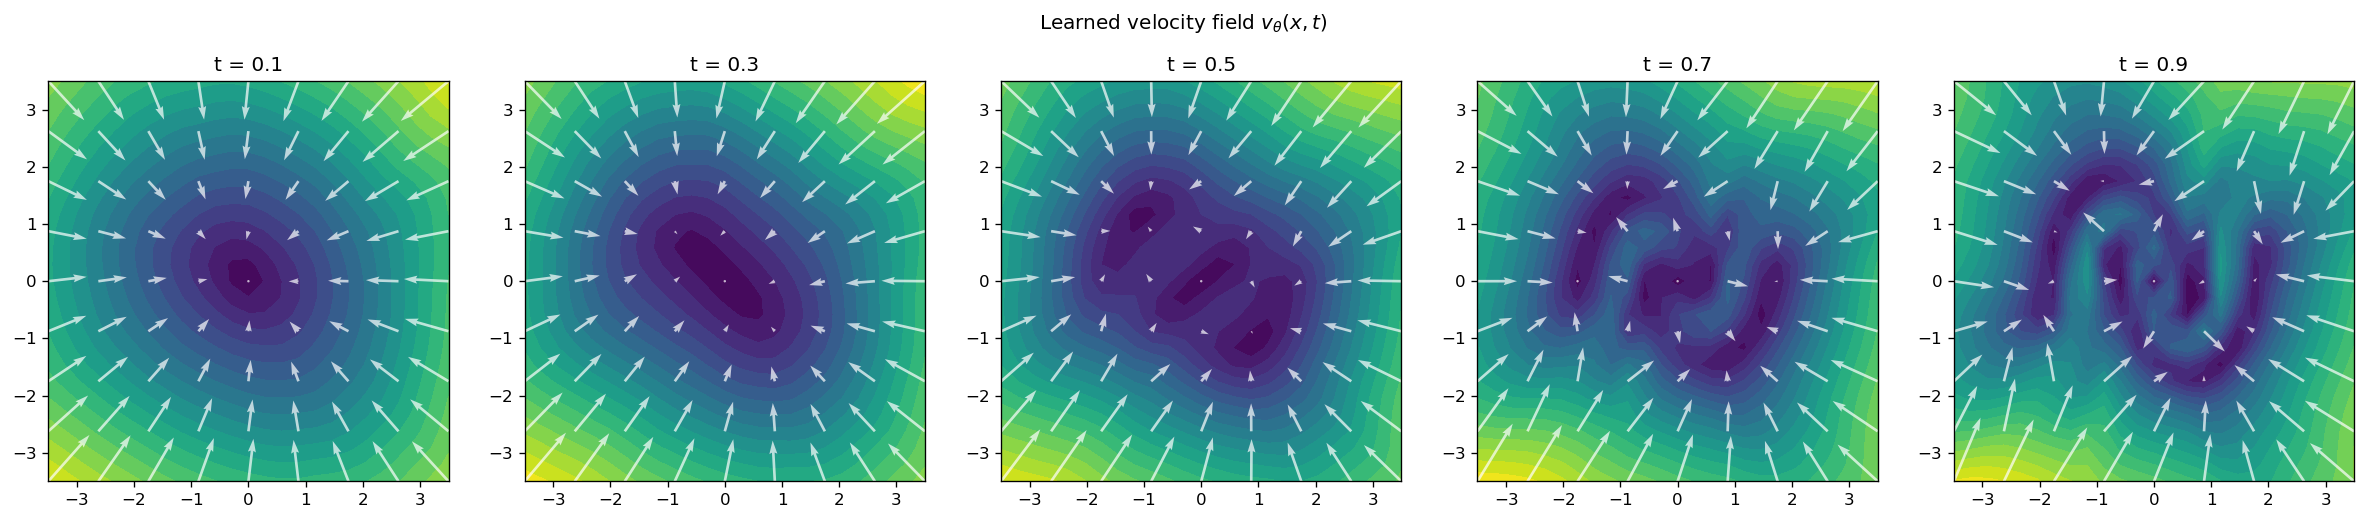

In [22]:
cfm.eval()
res    = 25
lo, hi = -3.5, 3.5
xs     = np.linspace(lo, hi, res)
ys     = np.linspace(lo, hi, res)
gx, gy = np.meshgrid(xs, ys)
grid   = torch.from_numpy(np.stack([gx.ravel(), gy.ravel()], axis=1)).float().to(DEVICE)

t_show = [0.1, 0.3, 0.5, 0.7, 0.9]
fig, axes = plt.subplots(1, len(t_show), figsize=(4*len(t_show), 4))

for ax, t_val in zip(axes, t_show):
    t_batch = torch.full((len(grid),), t_val, device=DEVICE)
    with torch.no_grad():
        v = cfm.network(grid, t_batch).cpu().numpy()
    v_mag = np.linalg.norm(v, axis=1).reshape(res, res)
    ax.contourf(gx, gy, v_mag, levels=20, cmap='viridis')
    sk = 3
    ax.quiver(gx[::sk,::sk], gy[::sk,::sk],
              v[:,0].reshape(res,res)[::sk,::sk],
              v[:,1].reshape(res,res)[::sk,::sk],
              color='white', alpha=0.7, scale=35)
    ax.set_title(f't = {t_val}')
    ax.set_aspect('equal')

plt.suptitle(r'Learned velocity field $v_\theta(x, t)$', y=1.02)
plt.tight_layout()
plt.show()

## 4  ODE trajectories (flow lines)

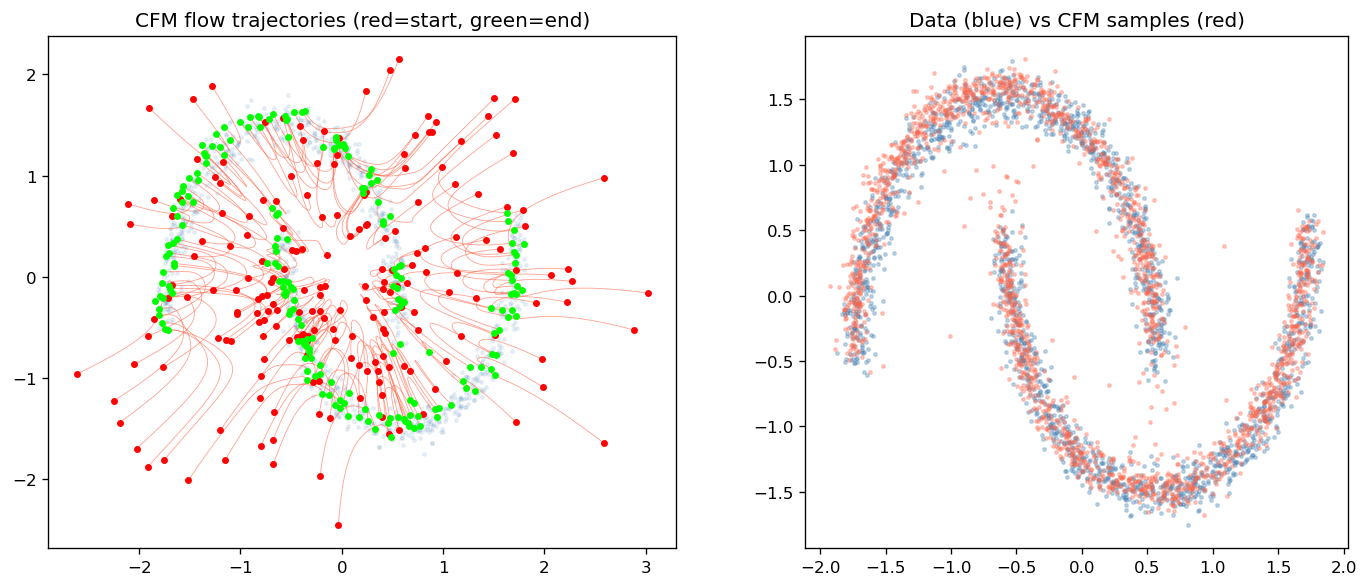

In [23]:
N_TRAJ = 200
x0_traj = torch.randn(N_TRAJ, 2, device=DEVICE)

with torch.no_grad():
    traj = cfm.trajectories(x0_traj, n_steps=50)   # (51, N, 2)

traj_np = traj.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: trajectory lines
ax = axes[0]
plot_samples(x0_np[:1000], ax=ax, alpha=0.1, s=4, color='steelblue')
for i in range(N_TRAJ):
    ax.plot(traj_np[:, i, 0], traj_np[:, i, 1],
            '-', linewidth=0.5, alpha=0.6, color='tomato')
# Start points
ax.scatter(traj_np[0, :, 0], traj_np[0, :, 1], s=10, c='red', zorder=4)
# End points
ax.scatter(traj_np[-1, :, 0], traj_np[-1, :, 1], s=10, c='lime', zorder=4)
ax.set_title('CFM flow trajectories (red=start, green=end)')
ax.set_aspect('equal')

# Right: final samples vs data
ax = axes[1]
x_gen = cfm.sample((2000, 2), device=DEVICE, n_steps=100, method='euler')
plot_samples(x0_np[:2000], ax=ax, alpha=0.3, s=4, color='steelblue',
             title='Data (blue) vs CFM samples (red)')
ax.scatter(x_gen.cpu()[:,0], x_gen.cpu()[:,1], s=4, alpha=0.3, c='tomato')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 5  NFE sweep: Euler {10, 20, 50, 100} and RK4 {10, 20}

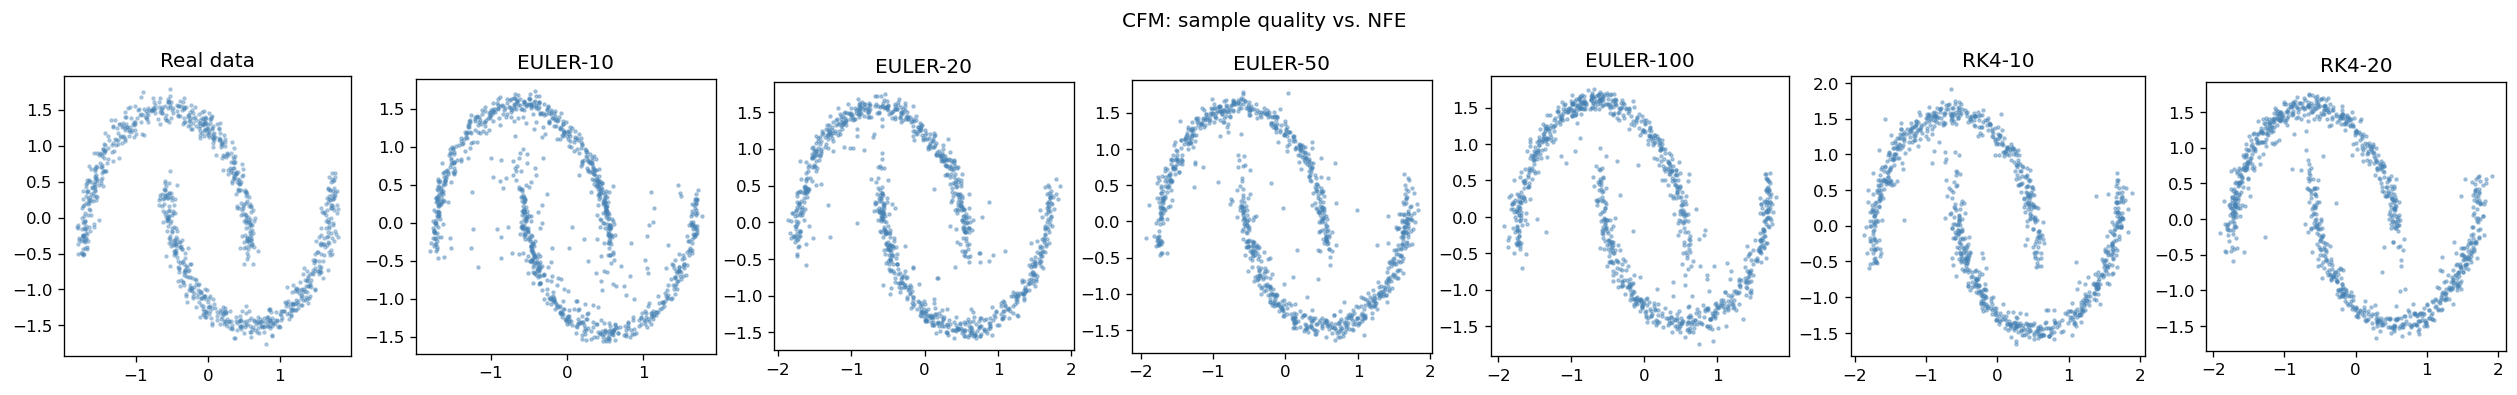

In [24]:
configs = [
    ('euler', 10), ('euler', 20), ('euler', 50), ('euler', 100),
    ('rk4',  10),  ('rk4',  20),
]

fig, axes = plt.subplots(1, len(configs)+1, figsize=(3*(len(configs)+1), 3))
plot_samples(x0_np[:1000], ax=axes[0], title='Real data', s=3)

for ax, (method, nfe) in zip(axes[1:], configs):
    x_s = cfm.sample((1000, 2), device=DEVICE, n_steps=nfe, method=method)
    plot_samples(x_s.cpu().numpy(), ax=ax,
                 title=f'{method.upper()}-{nfe}', s=3, alpha=0.4)

plt.suptitle('CFM: sample quality vs. NFE', y=1.02)
plt.tight_layout()
plt.show()

## 6  CFM vs. DDIM-50 side-by-side

Train a DDPM on the same dataset and compare.

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

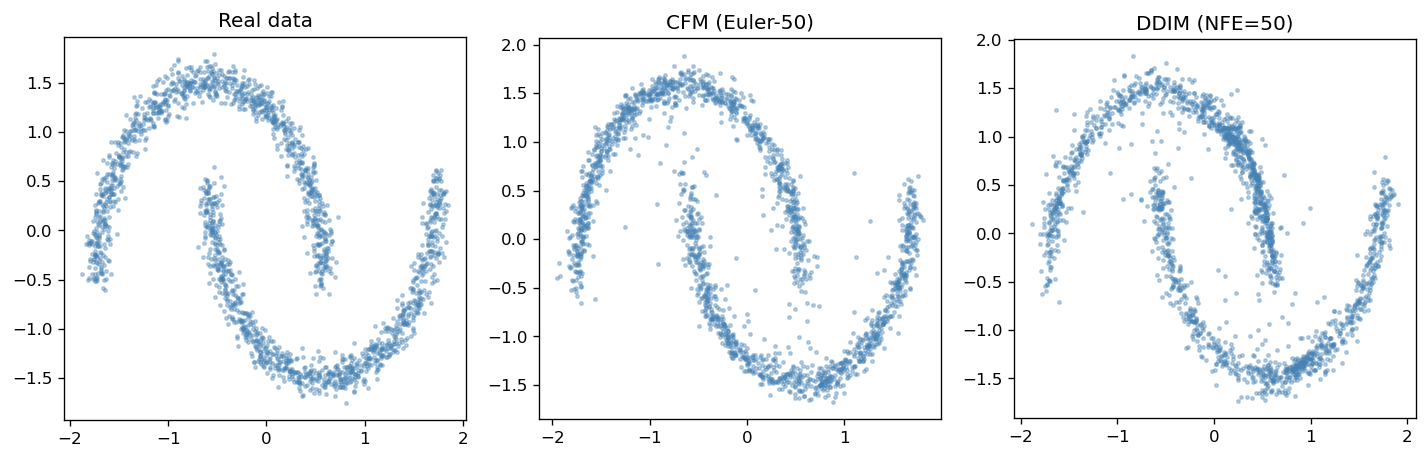

In [26]:
from diffusion_lab.schedulers import cosine_vp_schedule
from diffusion_lab.models     import DDPM, DDIMSampler

net_ddpm = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                   time_embed_dim=128).to(DEVICE)
ddpm     = DDPM(net_ddpm, cosine_vp_schedule(T=1000).to(DEVICE)).to(DEVICE)
tr_ddpm  = Trainer(ddpm, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
tr_ddpm.train(n_steps=20_000, log_every=10000)

x_ddim   = DDIMSampler(ddpm, eta=0.0, num_steps=50).sample((2000,2), device=DEVICE)
x_cfm    = cfm.sample((2000, 2), device=DEVICE, n_steps=50, method='euler')

from diffusion_lab.utils import compare_panels
compare_panels(
    x0_np[:2000],
    x_cfm.cpu().numpy(),
    x_ddim.cpu().numpy(),
    titles=['Real data', 'CFM (Euler-50)', 'DDIM (NFE=50)'],
)
plt.show()

## 7  Dataset sweep
Train CFM on all three datasets and compare.

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

spiral: done


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

moons: done


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

checkerboard: done


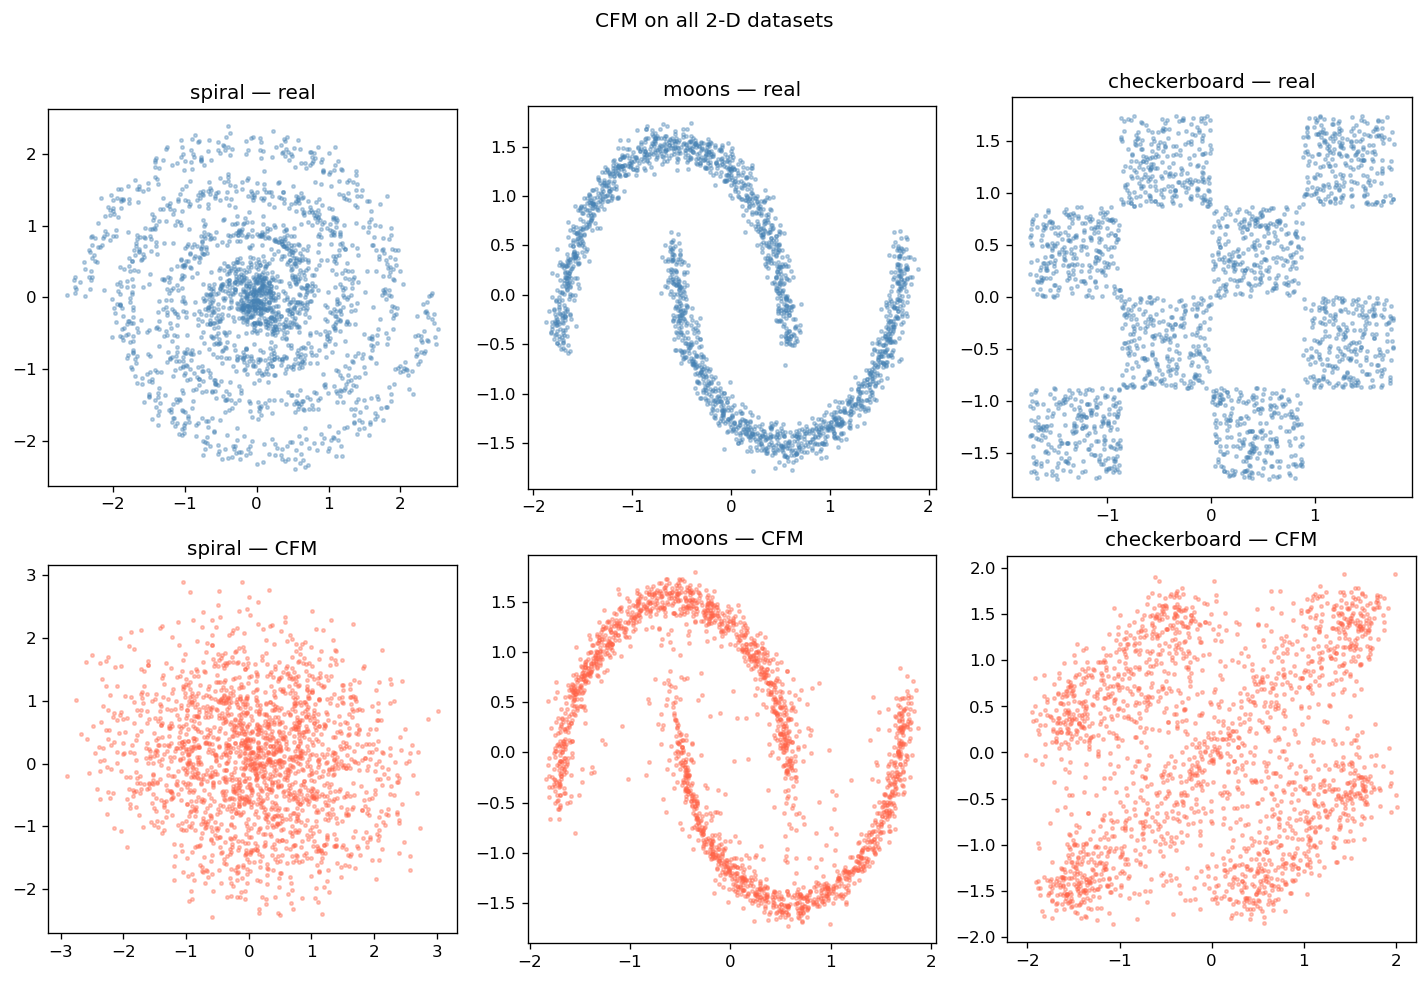

In [27]:
from diffusion_lab.data import DATASETS

results = {}
for ds in DATASETS:
    ldr = get_dataloader(ds, n=20_000, batch_size=512, seed=0, device=DEVICE)
    net = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                  time_embed_dim=128, residual=True).to(DEVICE)
    m   = CFM(net).to(DEVICE)
    Trainer(m, ldr, lr=3e-4, device=DEVICE).train(n_steps=10_000, log_every=1e9)
    results[ds] = m.sample((2000,2), device=DEVICE, n_steps=100).cpu().numpy()
    print(f'{ds}: done')

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ds in enumerate(DATASETS):
    real = make_dataset(ds, n=2000)
    plot_samples(real,          ax=axes[0][i], title=f'{ds} — real', color='steelblue')
    plot_samples(results[ds],   ax=axes[1][i], title=f'{ds} — CFM', color='tomato')
plt.suptitle('CFM on all 2-D datasets', y=1.01)
plt.tight_layout()
plt.show()